In [1]:
import gymnasium as gym
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")

# Examine the enviornment

In [2]:
from rlc.envs.fogofwar import FogGridEnv
env = FogGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(64)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 0  (row=0, col=0)


## Defining a fixed map layout for experimentation

In [3]:
env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.08,
    trap_density=0.05,
)

env.reset(seed = 41)

env.print_map()

A . . X . . . . . . . .
O . . . . . . . . . X .
. . O . . . X . . . . .
X . . . . . X . O . . .
. . . O . . . . . . O .
. O O . . . . . . . . .
. . . . . . . . . . . .
. . . . . O . . . . O .
. . . . . . . . . . . .
. . . . X . . . . X . .
. . O . . . . . . . . .
. . . . . . . . O . . G


In [4]:
# based of a randomized map with seed = 41

fixed_obstacle_tiles = [(4, 10),
 (3, 8),
 (7, 5),
 (4, 3),
 (7, 10),
 (5, 1),
 (2, 2),
 (1, 0),
 (11, 8),
 (10, 2),
 (5, 2)]

fixed_trap_tiles = [(9, 9), (0, 3), (3, 0), (2, 6), (1, 10), (3, 6), (9, 4)]


# Experiments

## 1st Case
- Regular tabular Q-Learning with a fixed map layout. The most basic example to start defining the elements of the project.

In [10]:
# Two environment instances: one for training, one for evaluation.

from rlc.utils.training import train
from rlc.agents.q_learning import QLearningAgent


train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed= 42
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True,
    seed=42
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

train_succ_rate = np.mean(history.eps_successess)

print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    77.4
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.1%


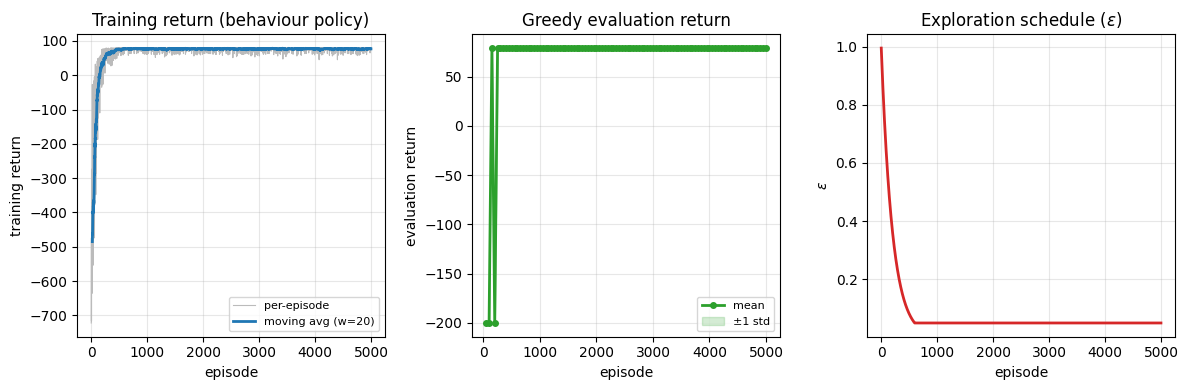

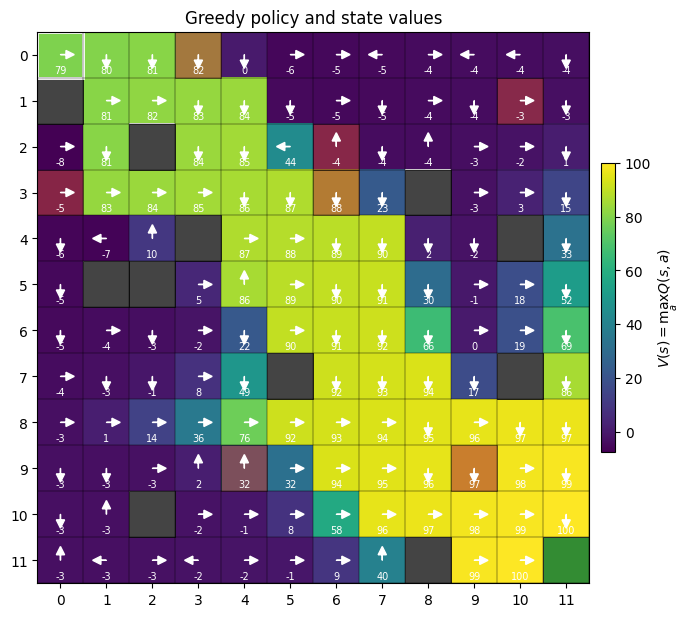

In [13]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## Variation of the 1st Case

- Same tabular Q-Learning model, but in this case we don't have a fixed map layout. Instead, each episode includes a completely new random layout.

In [14]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.08,
    trap_density=0.05,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.08,
    trap_density=0.05,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed = 42
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True,
    seed = 42
)


print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

train_succ_rate = np.mean(history.eps_successess)

print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -170.8
Final greedy evaluation return:    -827.6 (std 356.1)
Final evaluation success rate: 14.0%
Final mean episode length: 175.6 steps
Training success rate: 87.8%


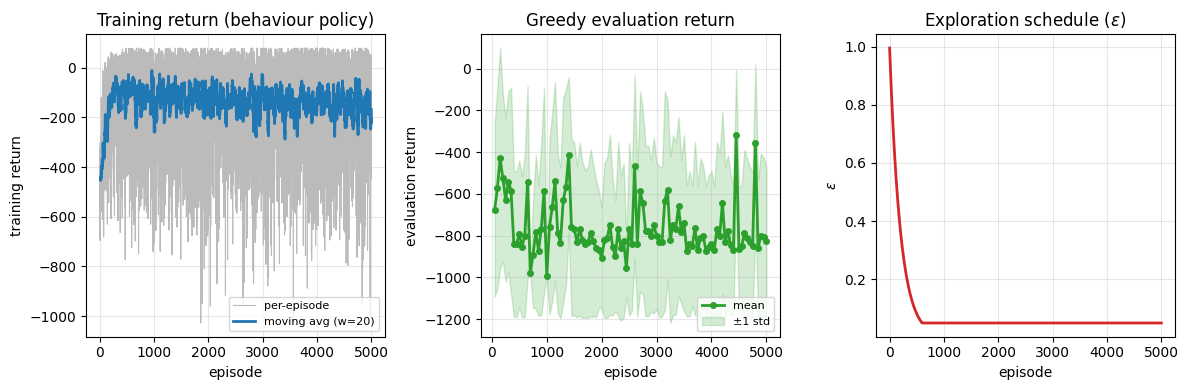

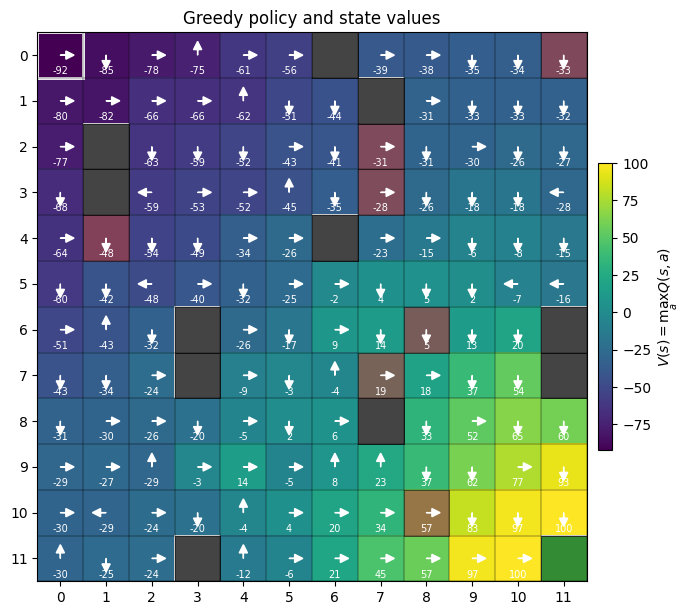

In [15]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## 2nd Case

- We create a local view for the agent, so it can lookup tiles that are 2 tiles from it.
- Each observation is now composed of the current position of the agent + the flattened local view.
- This, as the tabular model, will serve as the "index" in which Q-values will be updated for each agent+local view combination.

In [6]:
from rlc.agents.q_learning_wlocal import LocalQLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.08,
    trap_density=0.05,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.08,
    trap_density=0.05,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

agent = LocalQLearningAgent(
    n_actions=train_env.action_space.n,
    alpha=0.001,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed = 42
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    eval_map_setting="fixed",
    eval_map_seed= 123,
    progress=True,
    seed = 42
)


print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

train_succ_rate = np.mean(history.eps_successess)

print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -358.4
Final greedy evaluation return:    -356.0 (std 279.4)
Final evaluation success rate: 1.0%
Final mean episode length: 199.1 steps
Training success rate: 12.6%


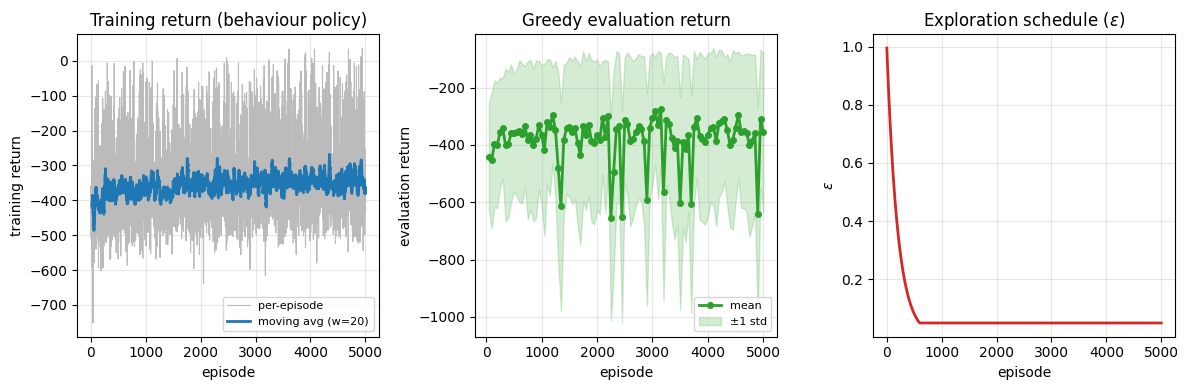

In [7]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()

# 3rd Case

- We include linera function approximation (LFA), creating a set of features that makes a better generalization in different scenarios.

In [5]:
from rlc.agents.q_learning_LFA import LFAQLearningAgent
from rlc.utils.features import LocalQuadrantFeatures
from rlc.utils.training import train

In [6]:
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.08,
    trap_density=0.05,
    vision_radius=2,
    local_view=True,
    render_mode="rgb_array",
)

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.08,
    trap_density=0.05,
    vision_radius=2,
    local_view=True,
    render_mode="rgb_array",
)

features = LocalQuadrantFeatures(
    height=train_env.height,
    width=train_env.width,
    vision_radius=2,
    exp_decay=1.0,
)

agent = LFAQLearningAgent(
    n_actions=train_env.action_space.n,
    feature_extractor=features,
    alpha=0.005,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.10,
    epsilon_decay=0.999,
    seed=42
)


history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=100,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    eval_map_setting="fixed",
    eval_map_seed= 123,
    seed=42,
    progress=True,
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print("Weight matrix size:", agent.weights.shape)
print("Weight norm:", np.linalg.norm(agent.weights))
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

train_succ_rate = np.mean(history.eps_successess)

print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.100
Mean return, last 50 train eps:    32.7
Final greedy evaluation return:    -74.8 (std 326.5)
Weight matrix size: (4, 34)
Weight norm: 105.97811949664118
Final evaluation success rate: 77.0%
Final mean episode length: 63.0 steps
Training success rate: 81.9%


In [7]:
final_returns = history.eval_map_returns[-1]
final_success = history.eval_map_success[-1]

In [8]:
for i, (ret, success) in enumerate(
    zip(final_returns, final_success)
):
    print(
        f"Map {i:3d}: "
        f"return={ret:7.1f}, "
        f"success={success}"
    )

Map   0: return=   79.0, success=True
Map   1: return= -200.0, success=False
Map   2: return=   79.0, success=True
Map   3: return=   79.0, success=True
Map   4: return= -920.0, success=False
Map   5: return=   79.0, success=True
Map   6: return=   79.0, success=True
Map   7: return=   79.0, success=True
Map   8: return=   79.0, success=True
Map   9: return=   79.0, success=True
Map  10: return= -200.0, success=False
Map  11: return= -924.0, success=False
Map  12: return=   79.0, success=True
Map  13: return= -200.0, success=False
Map  14: return=   65.0, success=True
Map  15: return=   79.0, success=True
Map  16: return= -214.0, success=False
Map  17: return=   79.0, success=True
Map  18: return= -200.0, success=False
Map  19: return=   79.0, success=True
Map  20: return=   65.0, success=True
Map  21: return=   79.0, success=True
Map  22: return=   65.0, success=True
Map  23: return=   79.0, success=True
Map  24: return= -928.0, success=False
Map  25: return=   79.0, success=True
Map 

In [35]:
layout = history.eval_maps[53]

eval_env.randomize_map = False
eval_env.set_layout(layout)

obs, _ = eval_env.reset()

In [36]:
eval_env.print_map()

A . . . . . . . . . . .
. . . O . X . . X X . .
. . . . . . O . . X . .
. . . . . . . . . . . .
. . O X X . . O . . . .
. . . . . . . . O . . O
. . . . . . . . O . . O
. . . . . . . . . . . .
. . . . . X . . . . . .
. . . . . O . . . . . .
. O . . . . . . . . . .
. . . . . . . . . O . G


In [37]:
positions = []

for _ in range(200):
    positions.append(eval_env._agent_pos)

    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, _ = eval_env.step(action)

    if terminated or truncated:
        break

print(positions)

[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (8, 1), (8, 2), (8, 3), (9, 3), (9, 4), (10, 4), (10, 5), (10, 6), (10, 7), (10, 8), (10, 9), (10, 10), (10, 11)]


In [38]:
eval_env.print_map()

S . . . . . . . . . . .
. . . O . X . . X X . .
. . . . . . O . . X . .
. . . . . . . . . . . .
. . O X X . . O . . . .
. . . . . . . . O . . O
. . . . . . . . O . . O
. . . . . . . . . . . .
. . . . . X . . . . . .
. . . . . O . . . . . .
. O . . . . . . . . . .
. . . . . . . . . O . A


In [8]:
len(positions)

22

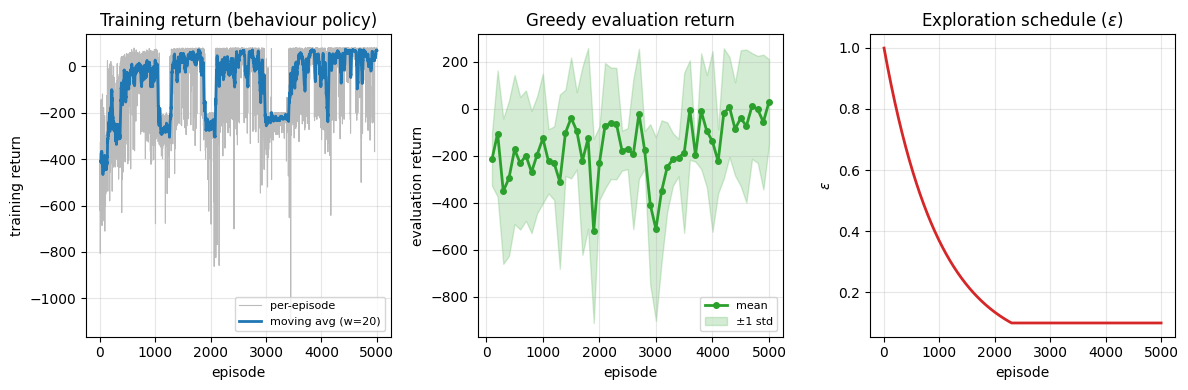

In [25]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()